Attempting Different Feature Selection Methods

In [41]:
FIGURES_DIR = "reports"
PROCESSED_DIR = "data/processed"
RANDOM_SEED = 42

In [42]:
import pandas as pd

data = r"C:\dev\Paddy_Prediction\data\transformed\paddy_preprocessed_tree.csv"
df = pd.read_csv(data)
df.head()

,LP_Mainfield(in Tonnes),Urea_40Days,Potassh_50Days,30DRain( in mm),30DAI(in mm),30_50DRain( in mm),30_50DAI(in mm),51_70DRain(in mm),51_70AI(in mm),71_105DRain(in mm),...,Wind Direction_D61_D90_NNE,Wind Direction_D61_D90_NNW,Wind Direction_D61_D90_SE,Wind Direction_D61_D90_SW,Wind Direction_D91_D120_NW,Wind Direction_D91_D120_S,Wind Direction_D91_D120_SSE,Wind Direction_D91_D120_W,Wind Direction_D91_D120_WSW,Paddy yield(in Kg)
0,1.587832,1.587832,1.587832,1.361570,-1.361570,1.381531,-1.381531,1.235600,-1.235600,1.381531,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,35028
1,1.587832,1.587832,1.587832,1.361570,-1.361570,1.381531,-1.381531,1.235600,-1.235600,1.381531,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,35412
2,1.587832,1.587832,1.587832,-0.347370,0.347370,-0.953675,0.953675,-1.270003,1.270003,-0.953675,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,36300
3,1.587832,1.587832,1.587832,-0.347370,0.347370,-0.953675,0.953675,-1.270003,1.270003,-0.953675,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,35016
4,1.587832,1.587832,1.587832,-0.968802,0.968802,-0.486634,0.486634,-0.090896,0.090896,-0.486634,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,34044


In [43]:
#Split features target
X = df.drop(columns=["Paddy yield(in Kg)"])
y = df["Paddy yield(in Kg)"]
X, y

(      LP_Mainfield(in Tonnes)  Urea_40Days  Potassh_50Days  30DRain( in mm)  \
 0                    1.587832     1.587832        1.587832         1.361570   
 1                    1.587832     1.587832        1.587832         1.361570   
 2                    1.587832     1.587832        1.587832        -0.347370   
 3                    1.587832     1.587832        1.587832        -0.347370   
 4                    1.587832     1.587832        1.587832        -0.968802   
 ...                       ...          ...             ...              ...   
 2784                -1.890383    -1.890383       -1.890383        -0.347370   
 2785                -1.890383    -1.890383       -1.890383        -0.968802   
 2786                -1.890383    -1.890383       -1.890383        -0.968802   
 2787                -1.890383    -1.890383       -1.890383         1.361570   
 2788                -1.890383    -1.890383       -1.890383         1.361570   
 
       30DAI(in mm)  30_50DRain( in mm

### Using Pearson Correlation to check and drop redundant fatures if any

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [45]:
IMPORTANT_FEATURES = [
    "Hectares ",
    "Urea_40Days",
    "Pest_60Day(in ml)",
    "Weed28D_thiobencarb"
]

In [46]:
def detect_ohe_columns(X):
    ohe_cols = []

    for col in X.columns:
        # Pattern-based detection
        if any(prefix in col for prefix in ["Wind Direction", "Agriblock", "Variety", "Soil Type", "Nursery"]):
            ohe_cols.append(col)
        # Value-based fallback
        elif set(X[col].dropna().unique()).issubset({0, 1}) and X[col].nunique() <= 2:
            ohe_cols.append(col)

    return ohe_cols


In [ ]:
def remove_correlated_features(X: pd.DataFrame, threshold: float = 0.90):
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    # Detect OHE features that are not to dropped
    ohe_cols = detect_ohe_columns(X)

    # Keep only continuous numeric features
    continuous_cols = [col for col in numeric_cols if col not in ohe_cols]

    print(f"[INFO] OHE Features Detected: {len(ohe_cols)}")
    print(f"[INFO] Continuous Features Used for Correlation: {len(continuous_cols)}")

    # Correlation only on continuous features
    corr_matrix = X[continuous_cols].corr().abs()

    # Heatmap (optional same as before)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(
        corr_matrix, mask=mask, cmap="coolwarm", center=0.5,
        linewidths=0.3, cbar_kws={"shrink": 0.7}, annot=False
    )

    # Upper triangle
    upper_tri = corr_matrix.where(mask == False)

    to_drop = set()

    for col in upper_tri.columns:
        correlated_with = upper_tri.index[upper_tri[col] > threshold].tolist()

        if correlated_with:
            candidates = correlated_with + [col]
            mean_corrs = corr_matrix[candidates].mean()
            worst = mean_corrs.idxmax()
            to_drop.add(worst)

    # Remove any features marked as important (if defined)
    if 'IMPORTANT_FEATURES' in globals():
        to_drop = to_drop - set(IMPORTANT_FEATURES)

    to_drop = list(to_drop)

    print(f"[Pearson Threshold = {threshold}]")
    print(f"Dropped {len(to_drop)} correlated features: {to_drop}")

    # Drop only from continuous features
    X_filtered = X.drop(columns=to_drop)

    return X_filtered, to_drop, ohe_cols

[INFO] OHE Features Detected: 28
[INFO] Continuous Features Used for Correlation: 35
[Pearson Threshold = 0.9]
Dropped 7 correlated features: ['Max temp_D91_D120', 'Min temp_D1_D30', 'LP_nurseryarea(in Tonnes)', '71_105DAI(in mm)', '71_105DRain(in mm)', 'Inst Wind Speed_D31_D60(in Knots)', '30_50DRain( in mm)']
Dropped 7 correlated features
Detected 28 OHE-style columns


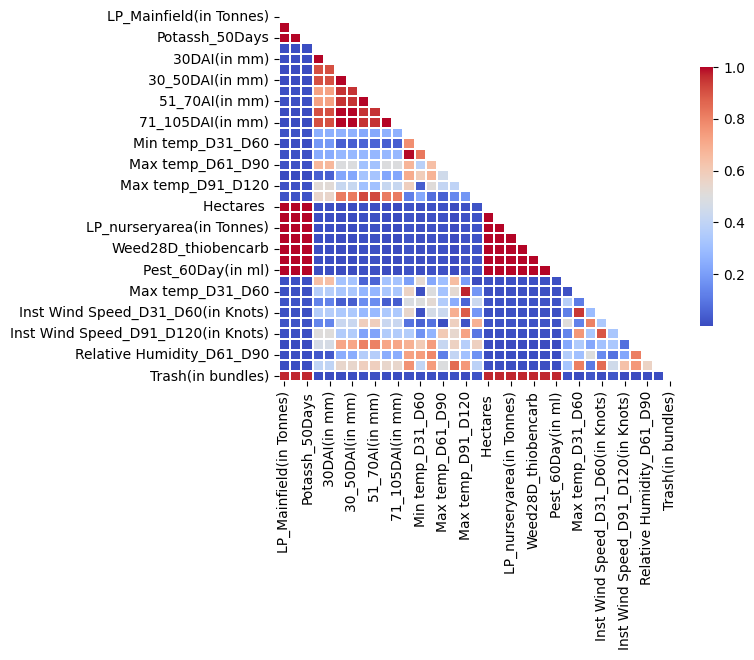

In [48]:
X, dropped_features, ohe_cols = remove_correlated_features(X, threshold=0.90)
print(f"Dropped {len(dropped_features)} correlated features")
print(f"Detected {len(ohe_cols)} OHE-style columns")

**Report**:

Important features that could play a major role in Paddy Yield (such as Hectares) was tracked to NOT be dropped. One-hot encoded categorical featured were tracked to be dropped before this pearson correlation test, so that this feature selection can only run on continuous values.

Pearson correlation removed features that are redundant as they highly correlate with each other. For example, redundant time windows in this dataset were removed, so was temperature windows, and wind speed

**Removed 7 features**

In [51]:
print(f"Original feature count: {len(df.columns) - 1}")  # Exclude target
print(f"Remaining feature count after dropping correlated features: {X.shape[1]}")


Original feature count: 63
Remaining feature count after dropping correlated features: 56
